In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

In [2]:
# -----------------------------------------------------------------------------
# TAHAP 1 & 2: Think - Inisialisasi Parameter & Profiling Dasar [3, 4]
# -----------------------------------------------------------------------------
def generate_base_data(n_rows=1000):
    """
    Membangun fondasi data transaksi normal berdasarkan statistik standar.
    """
    data = []
    start_date = datetime(2023, 11, 15)

    # Definisi kolom sesuai sumber [5]
    currencies = ['USD', 'EUR', 'GBP']
    asset_types = ['FIAT', 'CRYPTO']
    routes = ['ACH', 'WIRE', 'SEPA', 'BLOCKCHAIN']

    for i in range(n_rows):
        tx_id = f"tx-{981000 + i}"
        timestamp = start_date + timedelta(minutes=random.randint(1, 1440))
        sender = f"u-{random.randint(10000, 99999)}"
        receiver = f"m-{random.randint(10000, 99999)}"

        # Statistik normal: Transaksi retail kecil (mean=150, std=50) [4]
        amount = round(abs(np.random.normal(150, 50)), 2)

        currency = random.choice(currencies)
        asset = 'FIAT'
        route = random.choice(['ACH', 'WIRE', 'SEPA'])

        data.append([tx_id, timestamp.isoformat() + 'Z', sender, receiver,
                     amount, currency, asset, 'TRANSFER', route, 'VERIFIED', False])

    return data

In [3]:
# -----------------------------------------------------------------------------
# TAHAP 3 & 4: Act - Injeksi Skenario Kecurangan Spesifik [6, 7]
# -----------------------------------------------------------------------------
def inject_fraud_scenarios(data):
    """
    Menyuntikkan anomali berdasarkan tipologi TBML, Kripto, dan Deepfake.
    """
    # 1. Skenario TBML (Trade-Based Money Laundering) [6, 8]
    # Nilai besar, rute janggal (contoh: komoditas minyak/gas)
    for _ in range(5):
        tx_id = f"tx-tbml-{random.randint(100, 999)}"
        data.append([tx_id, datetime.now().isoformat(), 'c-iran-oil', 'c-china-refinery',
                     random.randint(500000, 2000000), 'USD', 'FIAT', 'TRADE_FINANCE',
                     'WIRE', 'VERIFIED', True])

    # 2. Skenario Crypto Layering & Mixers [6, 9]
    # Perpindahan cepat antar dompet dengan status UNVERIFIED
    for _ in range(5):
        tx_id = f"tx-mix-{random.randint(100, 999)}"
        data.append([tx_id, datetime.now().isoformat(), 'u-mix-ext-01', 'w-temp-441',
                     0.55, 'ETH', 'CRYPTO', 'TRANSFER', 'BLOCKCHAIN', 'UNVERIFIED', True])

    # 3. Skenario Generative AI / Deepfake KYC [7, 10]
    # Akun dengan identitas sintetis yang mencoba transaksi pertama bernilai tinggi
    for _ in range(5):
        tx_id = f"tx-ai-{random.randint(100, 999)}"
        data.append([tx_id, datetime.now().isoformat(), 'u-deepfake-gen', 'm-luxury-store',
                     9500, 'USD', 'FIAT', 'PURCHASE', 'ACH', 'PENDING', True])

    return data


In [4]:
# -----------------------------------------------------------------------------
# TAHAP 5 & 6: Learn, Plan & Export - Validasi & Generasi Akhir [2, 11]
# -----------------------------------------------------------------------------
def create_fraud_dataset():
    # Menjalankan workflow
    raw_data = generate_base_data(100) # Think
    enriched_data = inject_fraud_scenarios(raw_data) # Act

    # Membentuk DataFrame
    columns = ['id', 'timestamp', 'sender_id', 'receiver_id', 'amount',
               'currency', 'asset_type', 'transaction_type', 'route',
               'kyc_status', 'is_anomaly']
    df = pd.DataFrame(enriched_data, columns=columns)

    # Simulasi Human-in-the-Loop (Analisis Anomali) [11, 12]
    anomalies_count = df[df['is_anomaly'] == True].shape
    print(f"[INFO] Dataset berhasil dibuat dengan {len(df)} baris.")
    print(f"[INFO] Injeksi anomali terdeteksi: {anomalies_count} kasus.")

    # Ekspor ke CSV untuk Lini Pertahanan Keempat [2]
    file_name = 'fraud_synthetic_data_agentic_ai.csv'
    df.to_csv(file_name, index=False)
    print(f"[SUCCESS] File disimpan sebagai: {file_name}")

    return df

# Menjalankan fungsi utama
fraud_df = create_fraud_dataset()

# Menampilkan sampel data anomali untuk validasi QA [11]
print("\n--- Sampel Data Anomali (QA Validation) ---")
print(fraud_df[fraud_df['is_anomaly'] == True].head())

[INFO] Dataset berhasil dibuat dengan 115 baris.
[INFO] Injeksi anomali terdeteksi: (15, 11) kasus.
[SUCCESS] File disimpan sebagai: fraud_synthetic_data_agentic_ai.csv

--- Sampel Data Anomali (QA Validation) ---
              id                   timestamp   sender_id       receiver_id  \
100  tx-tbml-931  2026-03-06T10:24:10.478627  c-iran-oil  c-china-refinery   
101  tx-tbml-579  2026-03-06T10:24:10.478639  c-iran-oil  c-china-refinery   
102  tx-tbml-891  2026-03-06T10:24:10.478644  c-iran-oil  c-china-refinery   
103  tx-tbml-209  2026-03-06T10:24:10.478648  c-iran-oil  c-china-refinery   
104  tx-tbml-234  2026-03-06T10:24:10.478653  c-iran-oil  c-china-refinery   

        amount currency asset_type transaction_type route kyc_status  \
100  1854215.0      USD       FIAT    TRADE_FINANCE  WIRE   VERIFIED   
101   965487.0      USD       FIAT    TRADE_FINANCE  WIRE   VERIFIED   
102  1582426.0      USD       FIAT    TRADE_FINANCE  WIRE   VERIFIED   
103  1508697.0      USD      

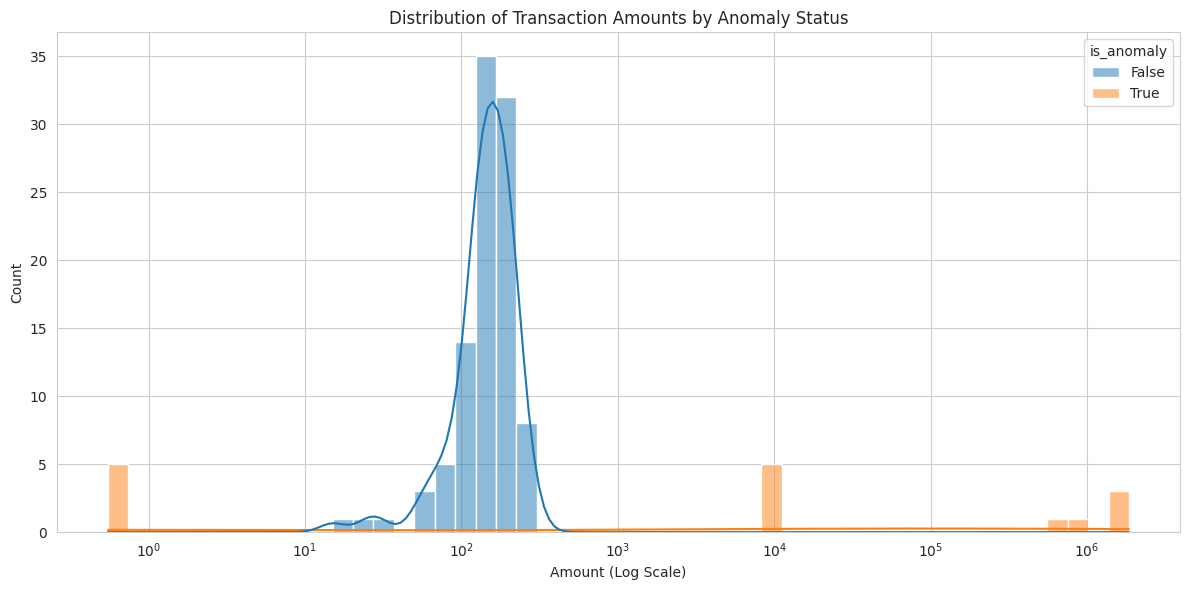

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style('whitegrid')

# 1. Distribution of Transaction Amounts (Normal vs. Anomaly)
plt.figure(figsize=(12, 6))
sns.histplot(data=fraud_df, x='amount', hue='is_anomaly', kde=True, bins=50, log_scale=True)
plt.title('Distribution of Transaction Amounts by Anomaly Status')
plt.xlabel('Amount (Log Scale)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

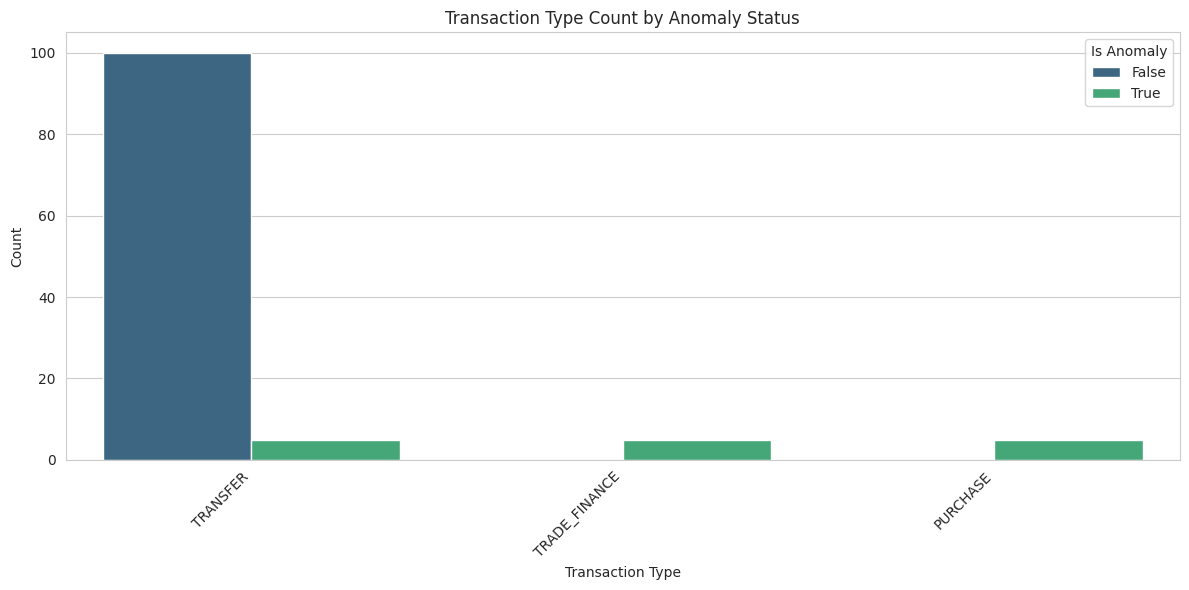

In [6]:
# 2. Count of Transaction Types (Normal vs. Anomaly)
plt.figure(figsize=(12, 6))
sns.countplot(data=fraud_df, x='transaction_type', hue='is_anomaly', palette='viridis')
plt.title('Transaction Type Count by Anomaly Status')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Is Anomaly')
plt.tight_layout()
plt.show()

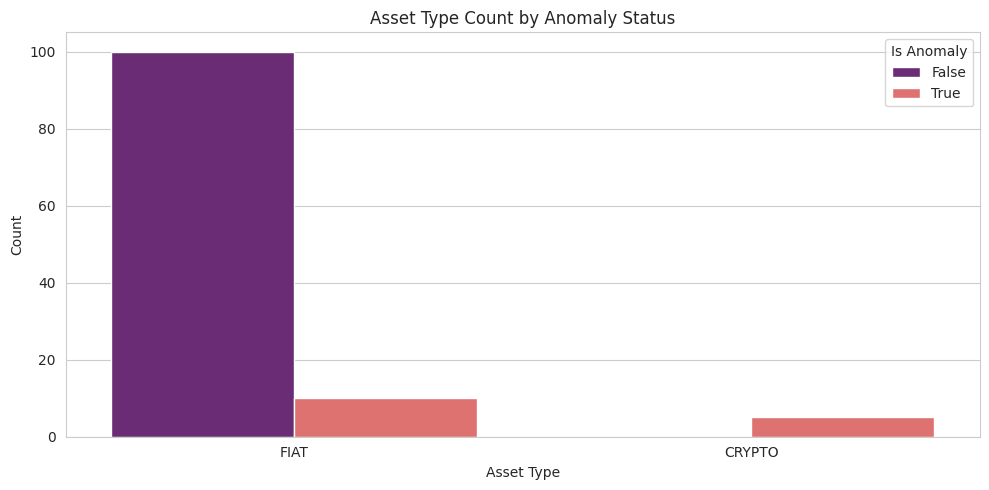

In [7]:
# 3. Count of Asset Types (Normal vs. Anomaly)
plt.figure(figsize=(10, 5))
sns.countplot(data=fraud_df, x='asset_type', hue='is_anomaly', palette='magma')
plt.title('Asset Type Count by Anomaly Status')
plt.xlabel('Asset Type')
plt.ylabel('Count')
plt.legend(title='Is Anomaly')
plt.tight_layout()
plt.show()